In [1]:
!pip install opencv-python

In [2]:
import cv2
print(cv2.__version__)

4.13.0


In [3]:
!pip install opencv-contrib-python

In [4]:
import urllib.request
url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(url, "haarcascade_frontalface_default.xml")
print("Downloaded!")

Downloaded!


In [5]:
import os
print(os.path.exists("haarcascade_frontalface_default.xml"))

True


Predicted Skin Tone: medium


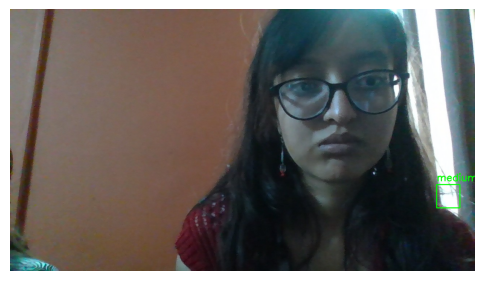

In [12]:
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os
import urllib.request

# --- Load model ---
model = load_model("skin_tone_model.h5")
class_labels = {0: 'deep', 1: 'medium', 2: 'fair'}  # update if needed

# --- Load face detector ---
if not os.path.exists("haarcascade_frontalface_default.xml"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml",
        "haarcascade_frontalface_default.xml"
    )
face_cascade = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

# --- Predict function ---
def predict_face(face_img):
    face_resized = cv2.resize(face_img, (224, 224))
    face_array = face_resized.astype('float32') / 255.0
    face_array = np.expand_dims(face_array, axis=0)
    prediction = model.predict(face_array, verbose=0)
    predicted_class = np.argmax(prediction)
    return class_labels[predicted_class]

# --- Open file picker ---
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
img_path = filedialog.askopenfilename(
    title="Select a photo",
    filetypes=[("Image files", "*.jpg *.jpeg *.png")]
)
root.destroy()

# --- Run detection ---
if img_path:
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=3, minSize=(30,30))

    if len(faces) == 0:
        print("No face detected. Try a clearer front-facing photo.")
    else:
        x, y, w, h = faces[0]
        face = img[y:y+h, x:x+w]
        label = predict_face(face)
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(img, label, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        print(f"Predicted Skin Tone: {label}")

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
else:
    print("No file selected.")

In [14]:
!pip install flask flask-cors

In [15]:
import flask
print(flask.__version__)

3.1.2


C:\Users\Acer\AppData\Local\Temp\ipykernel_38708\3294412508.py:2: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(flask.__version__)


Predicted Skin Tone: fair


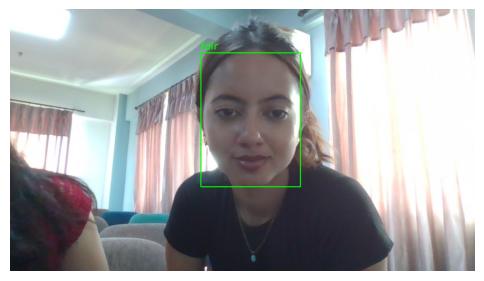

In [11]:
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import os

# --- Load model ---
model = load_model("skin_tone_model.h5")
class_labels = {0: 'deep', 1: 'medium', 2: 'fair'}

# --- Load DNN face detector (more accurate than haar cascade) ---
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

# --- Predict function ---
def predict_face(face_img):
    face_resized = cv2.resize(face_img, (224, 224))
    face_array = face_resized.astype('float32') / 255.0
    face_array = np.expand_dims(face_array, axis=0)
    prediction = model.predict(face_array, verbose=0)
    predicted_class = np.argmax(prediction)
    return class_labels[predicted_class]

# --- Open file picker ---
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()
img_path = filedialog.askopenfilename(
    title="Select a photo",
    filetypes=[("Image files", "*.jpg *.jpeg *.png")]
)
root.destroy()

# --- Run detection ---
if img_path:
    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()

    face_found = False
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > 0.5:  # only accept if 50%+ confident it's a face
            face_found = True
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            x1, y1, x2, y2 = box.astype("int")

            face = img[y1:y2, x1:x2]
            label = predict_face(face)

            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
            print(f"Predicted Skin Tone: {label}")
            break  # only process first face

    if not face_found:
        print("No face detected. Try a clearer front-facing photo.")
    else:
    
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(6,6))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
else:
    print("No file selected.")